## Dataset Preparation
### 1. Background
We'll be using [MIT's IndoorCVPR_09 dataset](https://web.mit.edu/torralba/www/indoor.html) for random backgrounds. As part of our preprocessing, we will do the following:
1. We don't need the images separated into different categories for our purposes, so to reduce overhead, we'll move all the images into one folder.
2. This dataset was also chosen because of the images' raw and unprocessed look. Compared to overly color graded images, these images will help us better simulate a camera environment.

In [2]:
# Moving all images from category subfolders into one folder
import os
import shutil

source_root = "../datasets/indoorCVPR_09/Images"
target_root = "../datasets/indoorCVPR_09_modified"

os.makedirs(target_root, exist_ok=True)

moved_count = 0
skipped_count = 0

for category in os.listdir(source_root):
    category_path = os.path.join(source_root, category)
    if not os.path.isdir(category_path):
        continue

    for filename in os.listdir(category_path):
        src_file = os.path.join(category_path, filename)
        if not os.path.isfile(src_file):
            continue

        name, ext = os.path.splitext(filename)
        target_name = filename
        dst_file = os.path.join(target_root, target_name)

        # Ensure filename uniqueness across categories
        if os.path.exists(dst_file):
            target_name = f"{category}_{name}{ext}"
            dst_file = os.path.join(target_root, target_name)

        if os.path.exists(dst_file):
            skipped_count += 1
            continue

        shutil.copy2(src_file, dst_file)
        moved_count += 1

print(f"Done. Copied {moved_count} images to: {target_root}")

Done. Copied 15618 images to: ../datasets/indoorCVPR_09_modified


We need to ensure that the images are acceptable for overlaying the clothing item colors.
Here, we will preprocess the images to ensure their colors are balanced and consistent.
1. Linearization: Subtracts sensor noise and undoes gamma compression to ensure color math is performed on the physical "true light" values.
2. Shades of Gray ($L^6$): A robust white balance that ignores large solid-colored objects (like a bright shirt) while using high-intensity highlights to neutralize the room's lighting tint.
3. LAB Space Processing: Separates color from brightness so that contrast can be adjusted without accidentally shifting the hue or saturation of the clothing.
4. CLAHE (Contrast Enhancement): Enhances the micro-textures of the fabric folds and weave locally, providing a detailed surface for realistic color overlays.
5. Neutral Ground Truth: Combined, these steps create a consistent, "daylight-neutral" canvas where any hex code or digital color will appear accurate and predictable.

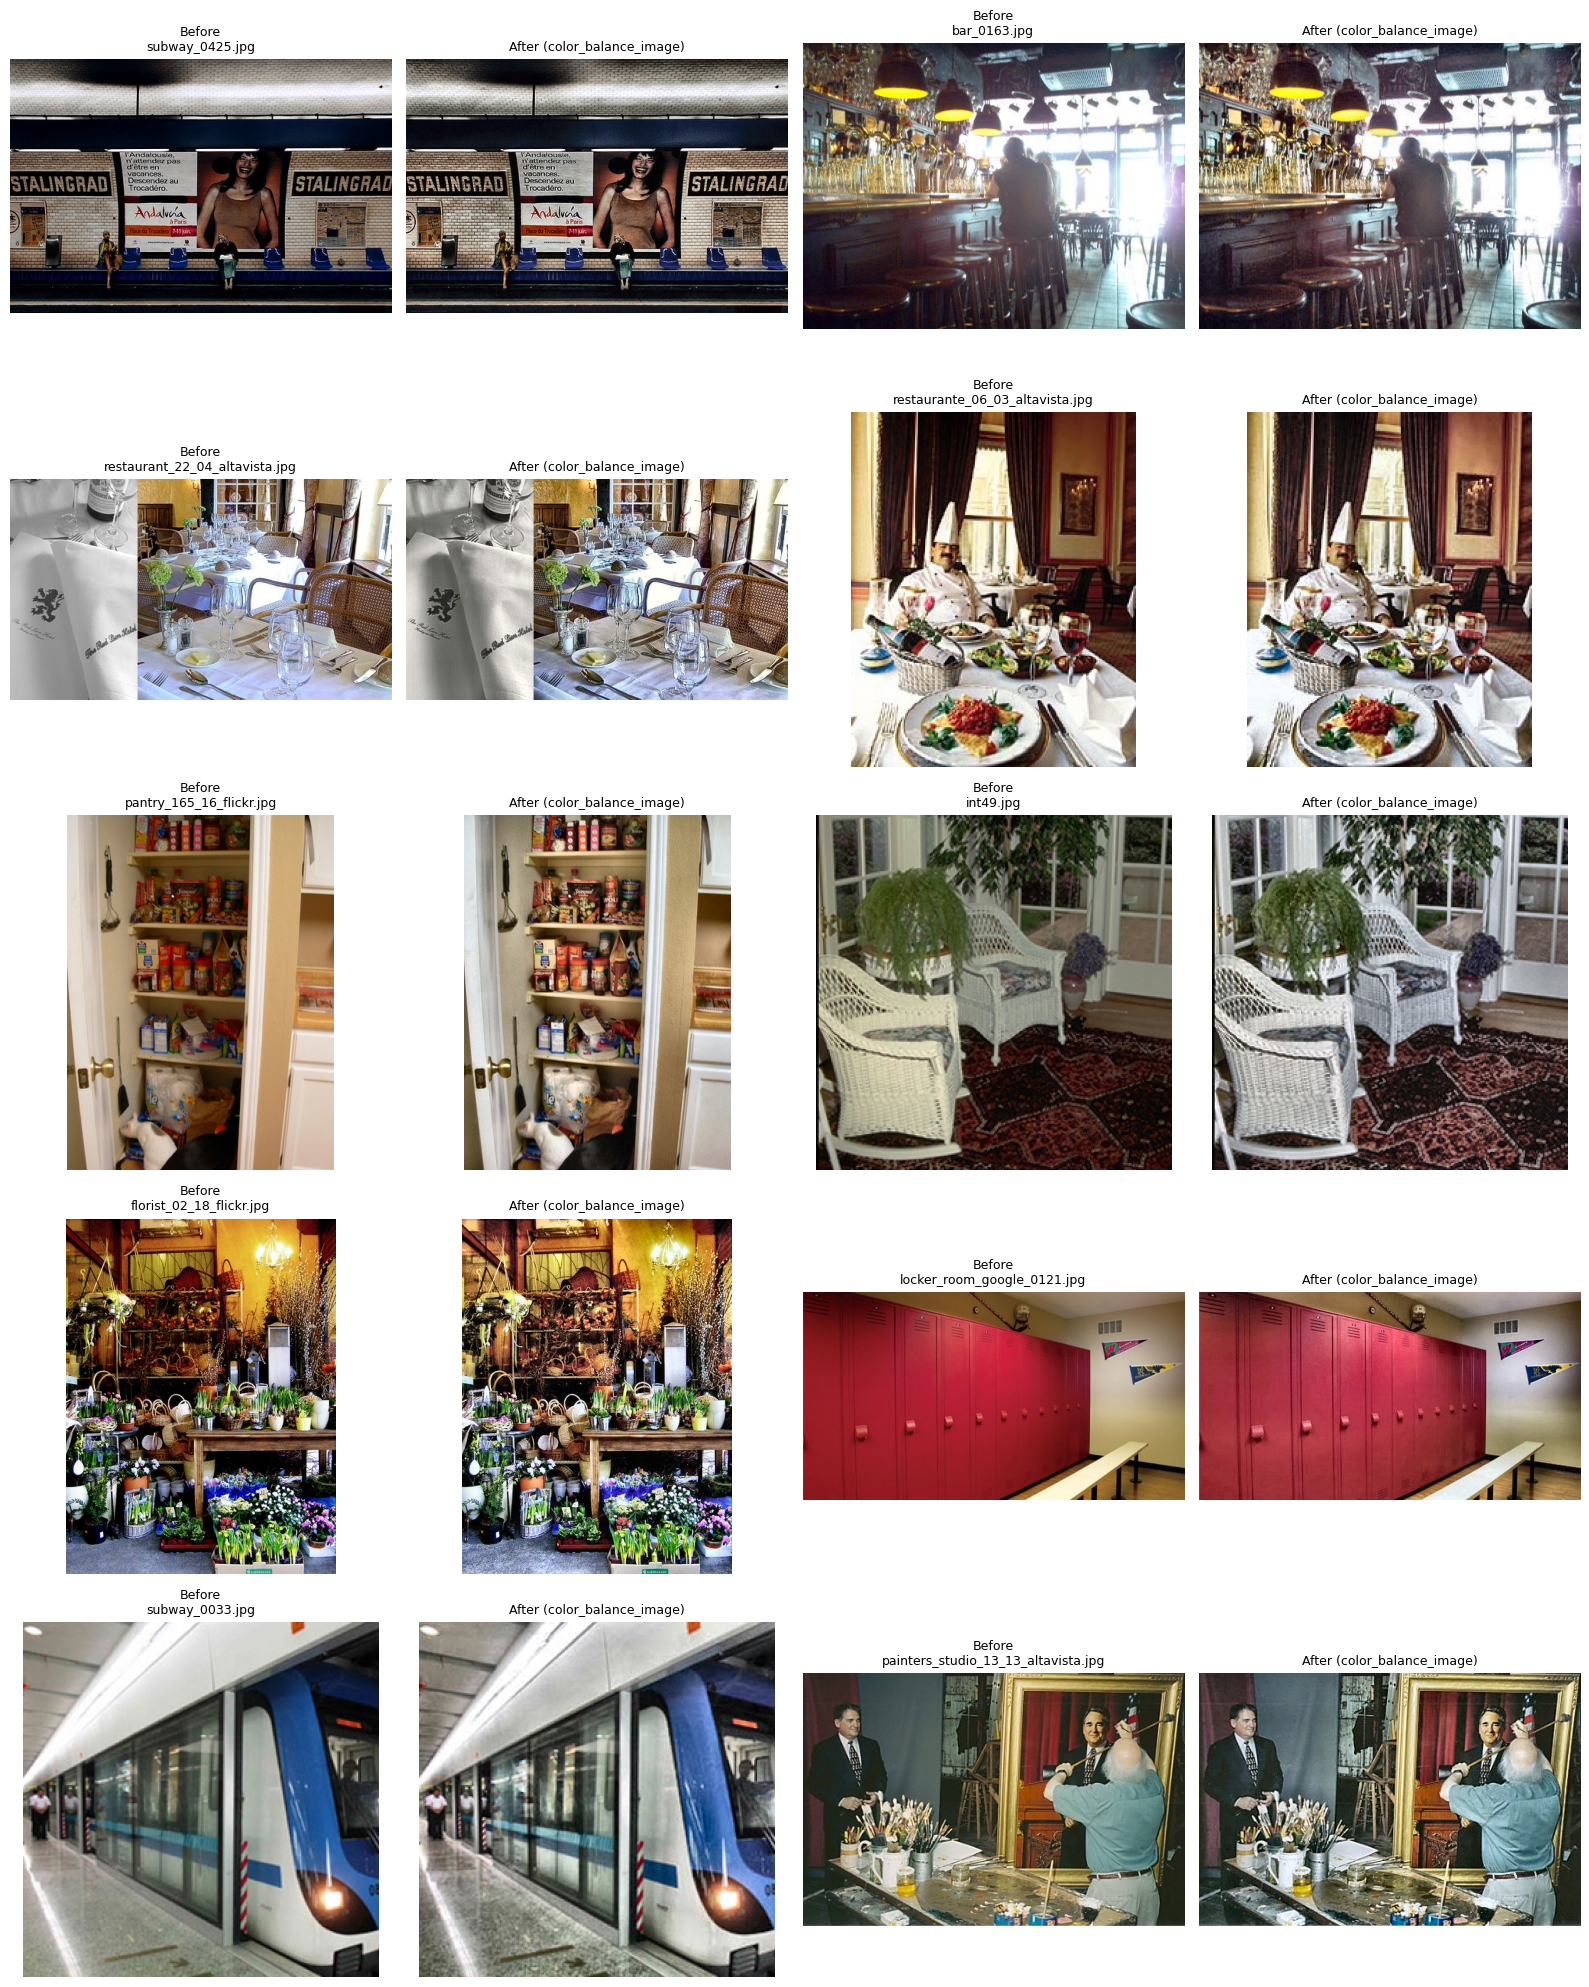

In [2]:
import sys
import os
import importlib
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
    
import utils.dataset_utils as dataset_utils
importlib.reload(dataset_utils)

# Use folder created earlier
image_dir = "../datasets/indoorCVPR_09_modified"

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
all_images = [
    os.path.join(image_dir, f)
    for f in os.listdir(image_dir)
    if f.lower().endswith(valid_exts)
]

if len(all_images) == 0:
    raise ValueError(f"No images found in: {image_dir}")

sample_n = min(10, len(all_images))
sample_paths = random.sample(all_images, sample_n)

# 5 rows x 4 cols => each row has 2 image pairs (before/after)
rows, cols = 5, 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 20))
axes = axes.flatten()

for i, path in enumerate(sample_paths):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        continue

    balanced_bgr = dataset_utils.color_balance_image(img_bgr.copy())

    # Convert for matplotlib display
    before_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if balanced_bgr.ndim == 2:
        after_disp = balanced_bgr
    else:
        after_disp = cv2.cvtColor(balanced_bgr, cv2.COLOR_BGR2RGB)

    # Handle float outputs safely
    if isinstance(after_disp, np.ndarray) and after_disp.dtype in (np.float32, np.float64):
        if after_disp.max() > 1.0:
            after_disp = np.clip(after_disp / 255.0, 0, 1)

    ax_before = axes[2 * i]
    ax_after = axes[2 * i + 1]

    ax_before.imshow(before_rgb)
    ax_before.set_title(f"Before\n{os.path.basename(path)}", fontsize=9)
    ax_before.axis("off")

    ax_after.imshow(after_disp, cmap="gray" if after_disp.ndim == 2 else None)
    ax_after.set_title("After (color_balance_image)", fontsize=9)
    ax_after.axis("off")

plt.tight_layout()
plt.show()



In [3]:
# We've verified that the color_balance_image function works correctly on a sample of images. The next step is to apply this function to the entire dataset.
# We don't need to create a new folder, we can overwrite the existing images since we have backups. The code will read each image, apply the color balance, and save it back to the same location. This will ensure that all images in the dataset are processed and ready for training.

processed_count = 0
saved_count = 0
failed_count = 0

for idx, img_path in enumerate(all_images, start=1):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        failed_count += 1
        continue

    try:
        balanced = dataset_utils.color_balance_image(img_bgr)

        # Ensure OpenCV-writable format
        if isinstance(balanced, np.ndarray) and balanced.dtype in (np.float32, np.float64):
            if balanced.max() <= 1.0:
                balanced = (balanced * 255.0).clip(0, 255).astype(np.uint8)
            else:
                balanced = balanced.clip(0, 255).astype(np.uint8)
        elif balanced.dtype != np.uint8:
            balanced = np.clip(balanced, 0, 255).astype(np.uint8)

        ok = cv2.imwrite(img_path, balanced)
        if ok:
            saved_count += 1
        else:
            failed_count += 1

    except Exception:
        failed_count += 1

    processed_count += 1
    if idx % 1000 == 0 or idx == len(all_images):
        print(f"Progress: {idx}/{len(all_images)}")

print(f"Done. Processed: {processed_count}, Saved: {saved_count}, Failed: {failed_count}")

Progress: 1000/15618
Progress: 2000/15618
Progress: 3000/15618
Progress: 4000/15618
Progress: 5000/15618
Progress: 6000/15618
Progress: 7000/15618
Progress: 8000/15618
Progress: 9000/15618
Progress: 10000/15618
Progress: 11000/15618
Progress: 12000/15618
Progress: 13000/15618
Progress: 14000/15618
Progress: 15000/15618
Progress: 15618/15618
Done. Processed: 15618, Saved: 15618, Failed: 0


### 2. Using Cleaned up Backgrounds for Dataset Generation

In [23]:
# imports again just in case we're running from this cell downwards
import matplotlib.pyplot as plt
import cv2

import os, sys, importlib
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
    
import utils.dataset_utils as dataset_utils
importlib.reload(dataset_utils)

<module 'utils.dataset_utils' from 'c:\\Users\\lifei\\OneDrive\\Desktop\\Personal Projects\\BBAIRL\\Clothing-Color-Recognition-ML-With-Synthetic-Dataset\\utils\\dataset_utils.py'>

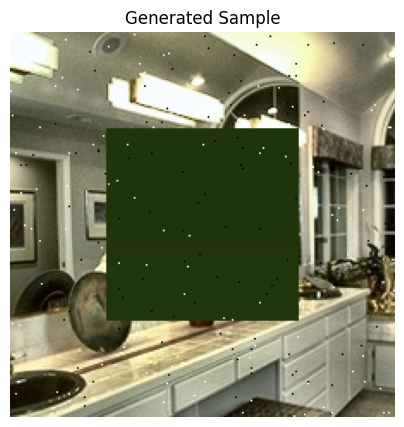

Label percentages: {'olive': 100.0}


In [24]:
dg = dataset_utils.DatasetGenerator(path_to_bgs="../datasets/indoorCVPR_09_modified")
generated_image, label_percentages = dg.generate()

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(generated_image, cv2.COLOR_BGR2RGB))
plt.title("Generated Sample")
plt.axis("off")
plt.show()

print("Label percentages:", label_percentages)

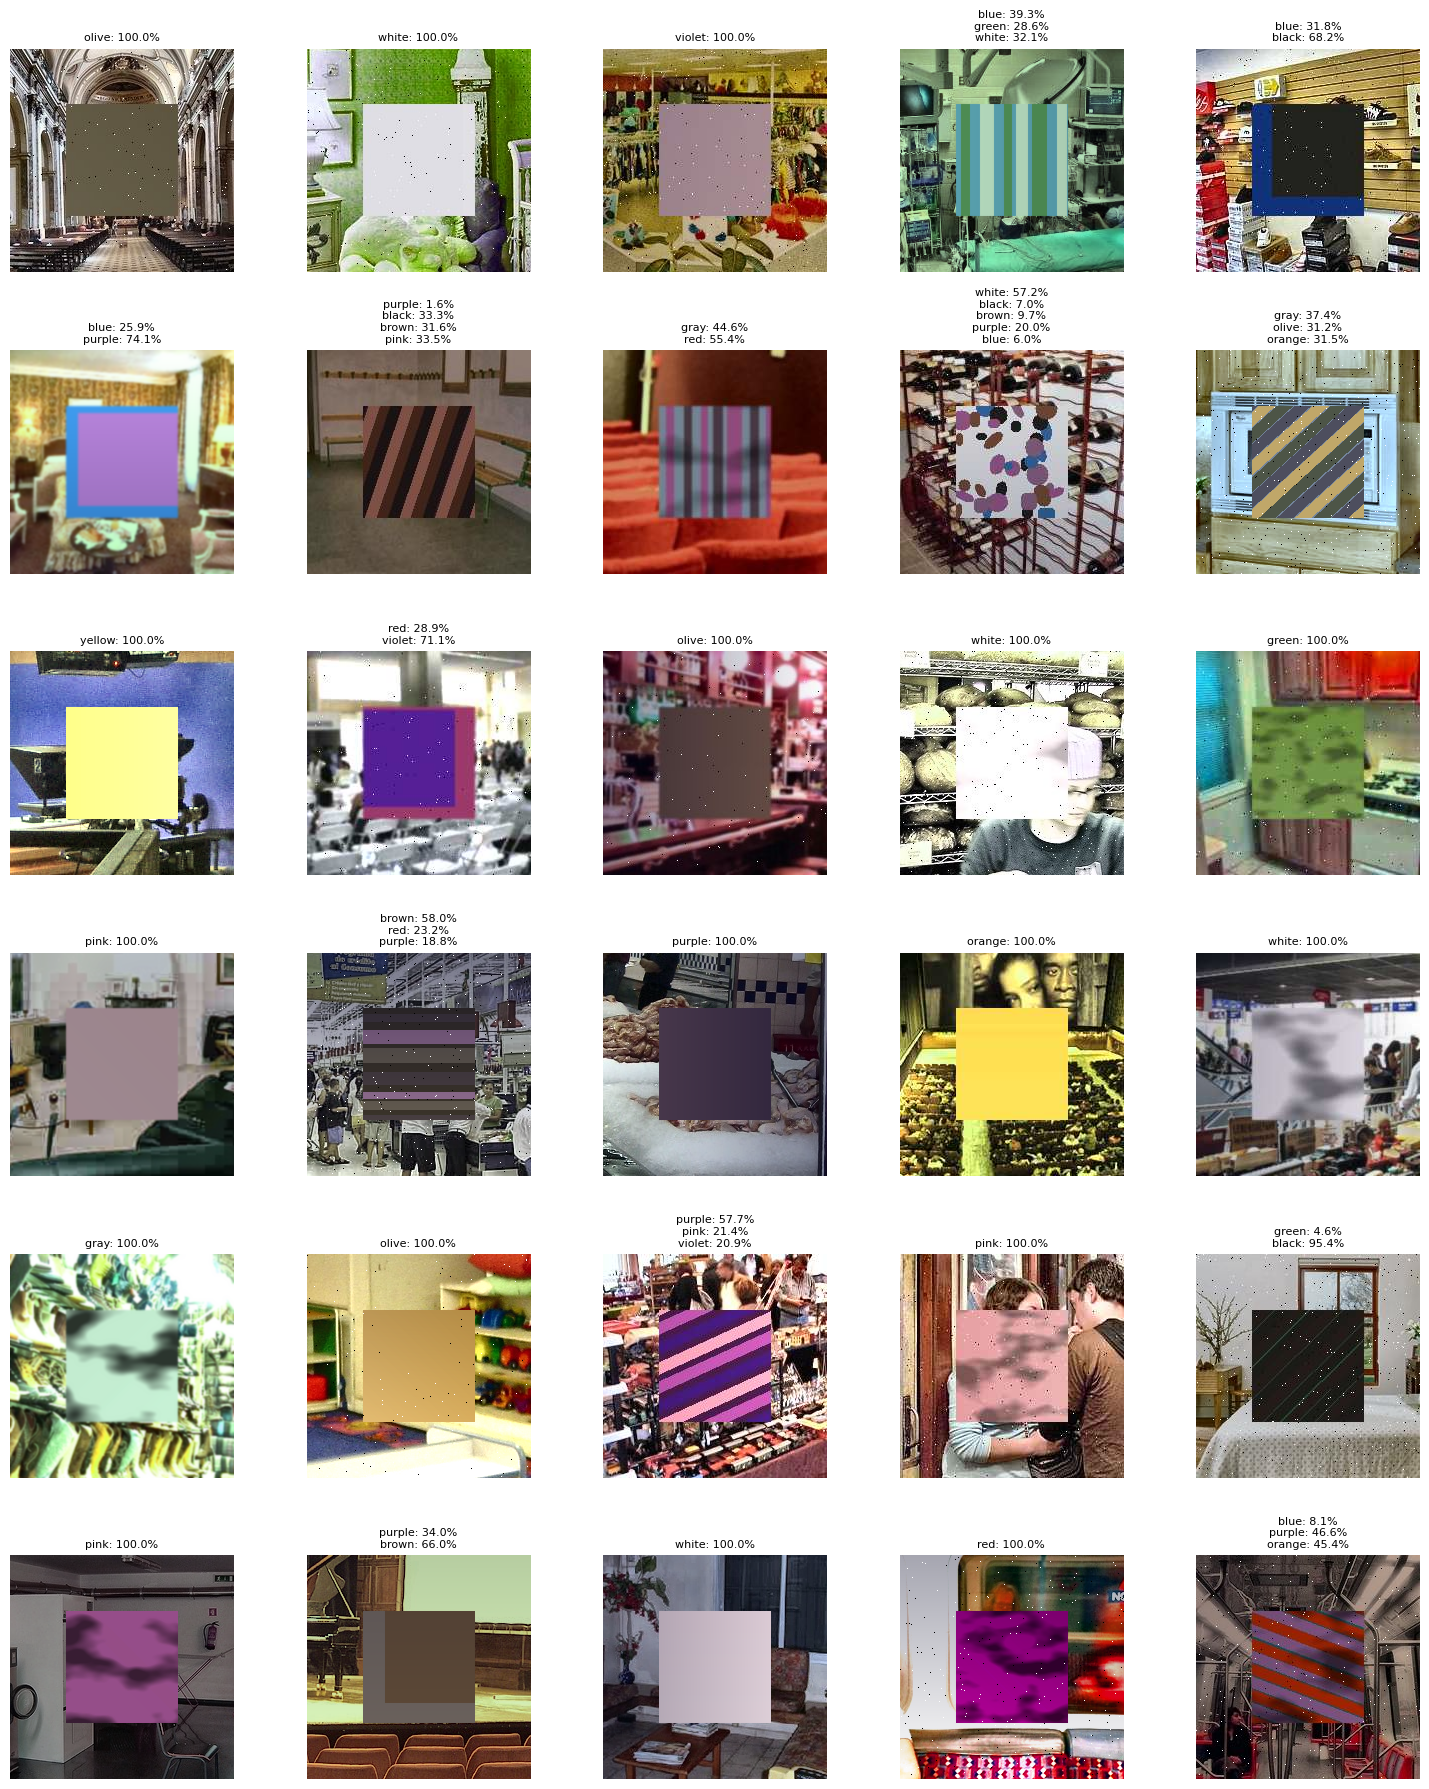

In [25]:
# I want to visualize a few more generated samples to see the variety and quality of the synthetic dataset. This will help me understand if the generator is producing diverse and realistic images that can be useful for training the model. I'll generate a grid of images to get a better sense of the overall output.
rows, cols = 6, 5
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.ravel()

for i in range(rows * cols):
    img_bgr, lbl = dg.generate()
    axes[i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    if isinstance(lbl, dict) and len(lbl) > 0:
        label_text = "\n".join(f"{k}: {v:.1f}%" for k, v in lbl.items())
        axes[i].set_title(label_text, fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()